In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import random

In [4]:
from faker import Faker
fake = Faker()

In [5]:
# Create telematics dataset
telematics_data = []

for i in range(1, 01):   # 100 rows
    telematics_data.append({
        "driver_id": i,
        "driver_name": fake.name(),
        "vehicle_id": fake.bothify(text="VH-####"),
        "trip_date": fake.date_between(start_date="-1y", end_date="today"),
        "speed_avg": round(random.uniform(30, 90), 2),          # average speed
        "max_speed": round(random.uniform(60, 130), 2),         # max speed
        "distance_km": round(random.uniform(5, 500), 2),        # trip distance
        "hard_brakes": random.randint(0, 15),
        "rapid_acceleration": random.randint(0, 12),
        "fuel_consumption_l": round(random.uniform(2, 50), 2),
        "idle_time_min": random.randint(0, 120),
        "driving_score": random.randint(50, 100),
        "city": fake.city(),
        "weather": random.choice(["Sunny", "Rainy", "Snowy", "Foggy", "Cloudy"]),
        "road_type": random.choice(["Highway", "Urban", "Rural"])
    })

In [7]:
# Convert into DataFrame
df = pd.DataFrame(telematics_data)

In [8]:
# Display first 10 rows
df.head(10)

,driver_id,driver_name,vehicle_id,trip_date,speed_avg,max_speed,distance_km,hard_brakes,rapid_acceleration,fuel_consumption_l,idle_time_min,driving_score,city,weather,road_type
0,1,Sherri Harris,VH-0171,2025-09-26,41.64,114.74,389.90,11,5,13.35,49,78,New Brianaville,Cloudy,Urban
1,2,Elizabeth Schmidt,VH-5069,2026-02-24,45.65,104.42,498.20,3,11,6.42,20,56,Scottville,Foggy,Urban
2,3,Megan Jackson,VH-0308,2026-01-20,41.27,95.30,8.85,1,3,22.73,18,62,Smithfurt,Sunny,Rural
3,4,Luis Byrd,VH-0957,2026-04-29,44.84,97.27,156.92,1,11,19.18,92,53,Angelaview,Foggy,Urban
4,5,Nancy Lewis,VH-6346,2025-06-23,41.70,119.68,38.53,13,2,2.98,84,55,Ronaldville,Sunny,Rural
5,6,Karen Huff,VH-9926,2025-10-04,54.94,103.37,472.53,8,2,2.99,101,55,South Adamshire,Sunny,Urban
6,7,Scott Henry,VH-3593,2025-06-20,30.44,72.82,10.51,0,8,40.18,36,82,Port Jenniferton,Rainy,Highway
7,8,Samantha Garcia,VH-5927,2026-02-26,65.08,81.97,156.84,9,10,10.75,90,71,Chadport,Rainy,Highway
8,9,Heather Martin,VH-3526,2025-12-14,86.40,95.81,401.68,4,8,21.61,81,92,Hernandezfort,Rainy,Highway
9,10,Heather Vance,VH-4566,2025-09-14,81.38,105.71,40.34,15,7,44.85,90,74,South Jameston,Cloudy,Highway


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   driver_id           500 non-null    int64  
 1   driver_name         500 non-null    object 
 2   vehicle_id          500 non-null    object 
 3   trip_date           500 non-null    object 
 4   speed_avg           500 non-null    float64
 5   max_speed           500 non-null    float64
 6   distance_km         500 non-null    float64
 7   hard_brakes         500 non-null    int64  
 8   rapid_acceleration  500 non-null    int64  
 9   fuel_consumption_l  500 non-null    float64
 10  idle_time_min       500 non-null    int64  
 11  driving_score       500 non-null    int64  
 12  city                500 non-null    object 
 13  weather             500 non-null    object 
 14  road_type           500 non-null    object 
dtypes: float64(4), int64(5), object(6)
memory usage: 58.7+ KB

In [10]:
df.describe()

,driver_id,speed_avg,max_speed,distance_km,hard_brakes,rapid_acceleration,fuel_consumption_l,idle_time_min,driving_score
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000
mean,250.500000,60.864640,95.727500,244.187300,7.366000,6.282000,26.098000,60.720000,74.218000
std,144.481833,16.984349,19.895145,145.606411,4.823959,3.631646,13.471973,33.829195,15.188016
min,1.000000,30.050000,60.020000,5.640000,0.000000,0.000000,2.200000,1.000000,50.000000
25%,125.750000,46.117500,79.147500,120.752500,3.000000,3.000000,14.170000,29.000000,61.000000
50%,250.500000,61.545000,95.905000,233.800000,7.000000,6.500000,26.680000,61.000000,73.000000
75%,375.250000,75.300000,113.062500,373.507500,12.000000,9.000000,37.557500,90.000000,87.000000
max,500.000000,89.900000,129.760000,498.200000,15.000000,12.000000,49.750000,120.000000,100.000000


In [11]:
df.dtypes

driver_id               int64
driver_name            object
vehicle_id             object
trip_date              object
speed_avg             float64
max_speed             float64
distance_km           float64
hard_brakes             int64
rapid_acceleration      int64
fuel_consumption_l    float64
idle_time_min           int64
driving_score           int64
city                   object
weather                object
road_type              object
dtype: object

# Creating a risk score

In [13]:
# Create Risk Score based on driving behavior

df["risk_score"] = (
    (df["speed_avg"] * 0.25) +
    (df["max_speed"] * 0.20) +
    (df["hard_brakes"] * 2.5) +
    (df["rapid_acceleration"] * 2.0) +
    (df["idle_time_min"] * 0.10) -
    (df["driving_score"] * 0.30)
)

# Round values
df["risk_score"] = df["risk_score"].round(2)
df

,driver_id,driver_name,vehicle_id,trip_date,speed_avg,max_speed,distance_km,hard_brakes,rapid_acceleration,fuel_consumption_l,idle_time_min,driving_score,city,weather,road_type,risk_score
0,1,Sherri Harris,VH-0171,2025-09-26,41.64,114.74,389.90,11,5,13.35,49,78,New Brianaville,Cloudy,Urban,52.36
1,2,Elizabeth Schmidt,VH-5069,2026-02-24,45.65,104.42,498.20,3,11,6.42,20,56,Scottville,Foggy,Urban,47.00
2,3,Megan Jackson,VH-0308,2026-01-20,41.27,95.30,8.85,1,3,22.73,18,62,Smithfurt,Sunny,Rural,21.08
3,4,Luis Byrd,VH-0957,2026-04-29,44.84,97.27,156.92,1,11,19.18,92,53,Angelaview,Foggy,Urban,48.46
4,5,Nancy Lewis,VH-6346,2025-06-23,41.70,119.68,38.53,13,2,2.98,84,55,Ronaldville,Sunny,Rural,62.76
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,496,Jeremy Hernandez,VH-9586,2025-07-02,49.48,70.71,142.77,0,10,22.33,16,79,Petersfort,Sunny,Highway,24.41
496,497,Jeffrey Mcpherson,VH-0944,2025-12-25,30.46,108.33,496.67,10,9,16.44,23,69,Sheaville,Sunny,Urban,53.88
497,498,Douglas Clark,VH-3245,2025-10-01,32.61,97.23,463.30,12,1,4.19,120,69,Stephaniebury,Foggy,Highway,50.90
498,499,Devon Robinson,VH-2097,2025-09-16,61.13,97.71,177.23,4,12,36.83,101,85,Thompsonville,Rainy,Rural,53.42


# Classifying Drivers (Safe vs Risky)

In [14]:
df["risk_category"] = np.where(df["risk_score"] > 50, "High Risk", "Low Risk")
df

,driver_id,driver_name,vehicle_id,trip_date,speed_avg,max_speed,distance_km,hard_brakes,rapid_acceleration,fuel_consumption_l,idle_time_min,driving_score,city,weather,road_type,risk_score,risk_category
0,1,Sherri Harris,VH-0171,2025-09-26,41.64,114.74,389.90,11,5,13.35,49,78,New Brianaville,Cloudy,Urban,52.36,High Risk
1,2,Elizabeth Schmidt,VH-5069,2026-02-24,45.65,104.42,498.20,3,11,6.42,20,56,Scottville,Foggy,Urban,47.00,Low Risk
2,3,Megan Jackson,VH-0308,2026-01-20,41.27,95.30,8.85,1,3,22.73,18,62,Smithfurt,Sunny,Rural,21.08,Low Risk
3,4,Luis Byrd,VH-0957,2026-04-29,44.84,97.27,156.92,1,11,19.18,92,53,Angelaview,Foggy,Urban,48.46,Low Risk
4,5,Nancy Lewis,VH-6346,2025-06-23,41.70,119.68,38.53,13,2,2.98,84,55,Ronaldville,Sunny,Rural,62.76,High Risk
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,496,Jeremy Hernandez,VH-9586,2025-07-02,49.48,70.71,142.77,0,10,22.33,16,79,Petersfort,Sunny,Highway,24.41,Low Risk
496,497,Jeffrey Mcpherson,VH-0944,2025-12-25,30.46,108.33,496.67,10,9,16.44,23,69,Sheaville,Sunny,Urban,53.88,High Risk
497,498,Douglas Clark,VH-3245,2025-10-01,32.61,97.23,463.30,12,1,4.19,120,69,Stephaniebury,Foggy,Highway,50.90,High Risk
498,499,Devon Robinson,VH-2097,2025-09-16,61.13,97.71,177.23,4,12,36.83,101,85,Thompsonville,Rainy,Rural,53.42,High Risk


In [15]:
df.groupby("risk_category")["driver_id"].count()

risk_category
High Risk    245
Low Risk     255
Name: driver_id, dtype: int64

# Visualization

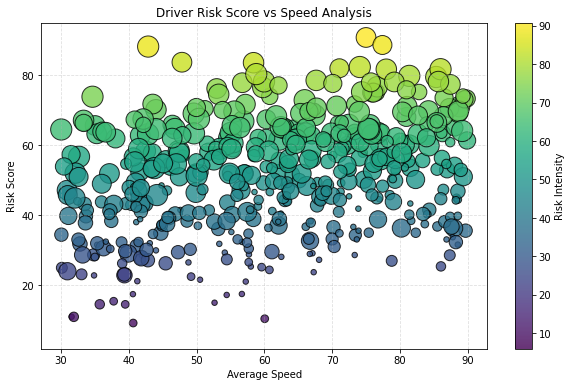

In [16]:
plt.figure(figsize=(10, 6))

# Color = risk score (gradient effect)
plt.scatter(
    df["speed_avg"],
    df["risk_score"],
    c=df["risk_score"],      # color based on risk
    cmap="viridis",          # color palette
    s=df["hard_brakes"] * 30, # size based on hard brakes
    alpha=0.8,
    edgecolor="black"
)

plt.title("Driver Risk Score vs Speed Analysis")
plt.xlabel("Average Speed")
plt.ylabel("Risk Score")

plt.colorbar(label="Risk Intensity")  # shows color meaning
plt.grid(True, linestyle="--", alpha=0.4)

plt.show()

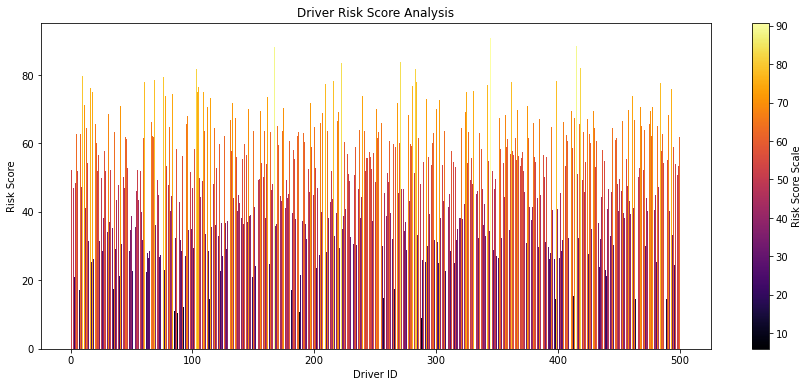

In [17]:
plt.figure(figsize=(15, 6))

# Normalize risk score for color mapping (0 → 1 scale)
norm = mpl.colors.Normalize(vmin=df["risk_score"].min(), vmax=df["risk_score"].max())
cmap = plt.cm.inferno

# Create bar colors based on risk score
colors = cmap(norm(df["risk_score"]))

plt.bar(df["driver_id"], df["risk_score"], color=colors)

plt.title("Driver Risk Score Analysis")
plt.xlabel("Driver ID")
plt.ylabel("Risk Score")

# Add colorbar
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])  # required for matplotlib
plt.colorbar(sm, label="Risk Score Scale")

plt.show()

# "Project 2: Digital Insurance Quote Optimization
        # Title : Online Auto Insurance Quote Funnel Analytics About the Project" 

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Sample Dataset (Simulating Website Behavior)

In [19]:
np.random.seed(42)

n = 500

df = pd.DataFrame({
    "user_id": range(1, n+1),
    "landing_page_view": np.random.choice([1, 0], n, p=[0.9, 0.1]),
    "form_started": np.random.choice([1, 0], n, p=[0.7, 0.3]),
    "form_completed": np.random.choice([1, 0], n, p=[0.5, 0.5]),
    "quote_submitted": np.random.choice([1, 0], n, p=[0.4, 0.6]),
    "policy_bought": np.random.choice([1, 0], n, p=[0.25, 0.75]),
    "ab_test_group": np.random.choice(["A", "B"], n),
    "time_spent_sec": np.random.randint(30, 600, n)
})

In [20]:
df

,user_id,landing_page_view,form_started,form_completed,quote_submitted,policy_bought,ab_test_group,time_spent_sec
0,1,1,1,1,0,0,A,441
1,2,0,1,0,0,1,A,520
2,3,1,1,0,1,0,A,78
3,4,1,0,0,1,1,A,593
4,5,1,1,0,1,0,B,131
...,...,...,...,...,...,...,...,...
495,496,1,1,0,0,0,A,90
496,497,1,0,0,0,0,A,348
497,498,1,1,1,1,0,B,81
498,499,0,0,1,1,0,B,182


# Funnel analysis

In [21]:
funnel = {
    "Landing Page": df["landing_page_view"].sum(),
    "Form Started": df["form_started"].sum(),
    "Form Completed": df["form_completed"].sum(),
    "Quote Submitted": df["quote_submitted"].sum(),
    "Policy Bought": df["policy_bought"].sum()
}

funnel_df = pd.DataFrame(list(funnel.items()), columns=["Stage", "Users"])

print(funnel_df)

             Stage  Users
0     Landing Page    445
1     Form Started    366
2   Form Completed    238
3  Quote Submitted    197
4    Policy Bought    116


# Funnel Visualization

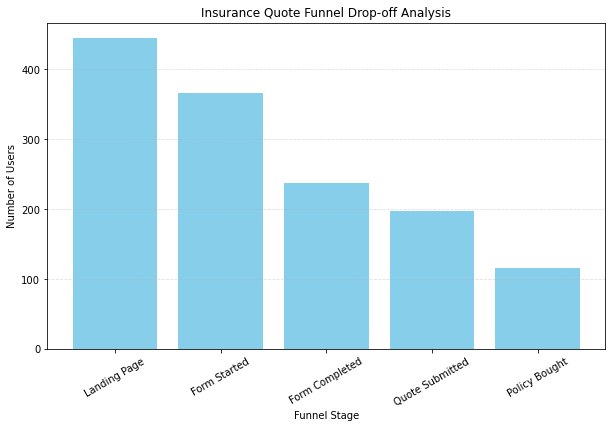

In [22]:
plt.figure(figsize=(10,6))

plt.bar(funnel_df["Stage"], funnel_df["Users"], color="skyblue")

plt.title("Insurance Quote Funnel Drop-off Analysis")
plt.xlabel("Funnel Stage")
plt.ylabel("Number of Users")

plt.xticks(rotation=30)
plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.show()

# Drop-off Rate Calculation

In [23]:
funnel_df["Drop-off"] = funnel_df["Users"].shift(1) - funnel_df["Users"]
funnel_df["Drop-off %"] = (funnel_df["Drop-off"] / funnel_df["Users"].shift(1)) * 100

print(funnel_df)

             Stage  Users  Drop-off  Drop-off %
0     Landing Page    445       NaN         NaN
1     Form Started    366      79.0   17.752809
2   Form Completed    238     128.0   34.972678
3  Quote Submitted    197      41.0   17.226891
4    Policy Bought    116      81.0   41.116751


# A/B Test Analysis (Conversion Rate)

In [24]:
ab_summary = df.groupby("ab_test_group")["policy_bought"].mean() * 100

print("A/B Test Conversion Rate (%)")
print(ab_summary)

A/B Test Conversion Rate (%)
ab_test_group
A    24.409449
B    21.951220
Name: policy_bought, dtype: float64


# A/B Test Visualization

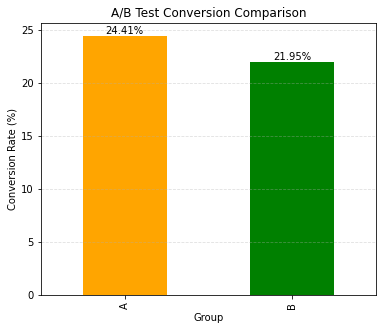

In [25]:
plt.figure(figsize=(6,5))

ab_summary.plot(kind="bar", color=["orange", "green"])

plt.title("A/B Test Conversion Comparison")
plt.xlabel("Group")
plt.ylabel("Conversion Rate (%)")
plt.grid(axis="y", linestyle="--", alpha=0.4)

# Add value labels on top of bars
for i, v in enumerate(ab_summary.values):
    plt.text(i, v + 0.2, f"{v:.2f}%", ha="center", fontsize=10)

plt.show()

# Time Spent Analysis vs Conversion

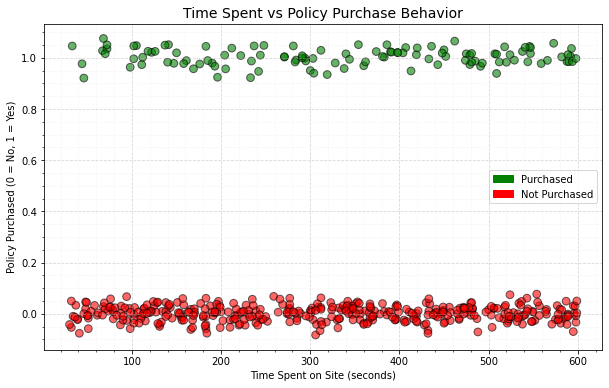

In [26]:

plt.figure(figsize=(10,6))

# Add slight jitter so points don't overlap (important for 0/1 data)
y_jitter = df["policy_bought"] + np.random.normal(0, 0.03, len(df))

# Color based on purchase
colors = df["policy_bought"].map({0: "red", 1: "green"})

# Scatter plot
plt.scatter(
    df["time_spent_sec"],
    y_jitter,
    c=colors,
    alpha=0.6,
    s=60,
    edgecolor="black"
)

# Titles
plt.title("Time Spent vs Policy Purchase Behavior", fontsize=14)
plt.xlabel("Time Spent on Site (seconds)")
plt.ylabel("Policy Purchased (0 = No, 1 = Yes)")

# Grid (major + minor)
plt.grid(True, which="major", linestyle="--", alpha=0.5)
plt.minorticks_on()
plt.grid(True, which="minor", linestyle=":", alpha=0.2)

# Custom legend
import matplotlib.patches as mpatches
legend_elements = [
    mpatches.Patch(color='green', label='Purchased'),
    mpatches.Patch(color='red', label='Not Purchased')
]
plt.legend(handles=legend_elements)

plt.show()

# Funnel chart

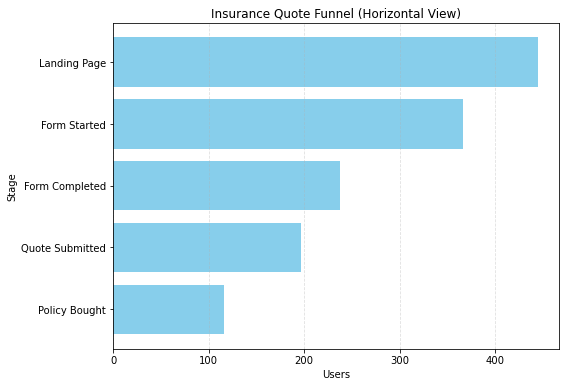

In [27]:
plt.figure(figsize=(8,6))

stages = funnel_df["Stage"]
users = funnel_df["Users"]

plt.barh(stages, users, color="skyblue")

plt.title("Insurance Quote Funnel (Horizontal View)")
plt.xlabel("Users")
plt.ylabel("Stage")

plt.gca().invert_yaxis()  # makes funnel flow top → bottom

plt.grid(axis="x", linestyle="--", alpha=0.4)

plt.show()

# Advance Funnel chart

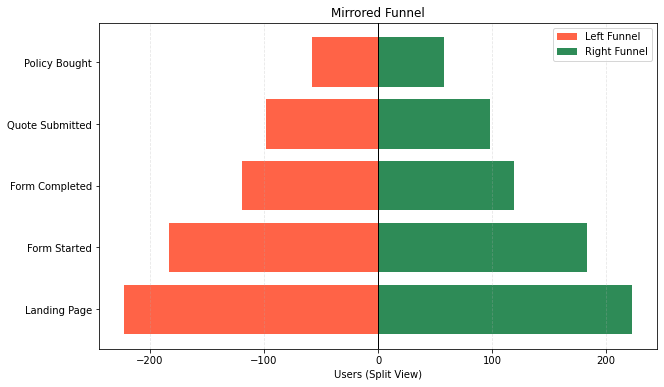

In [28]:
stages = funnel_df["Stage"]
users = funnel_df["Users"]

# Create mirrored values
left_side = -users / 2
right_side = users / 2

y = np.arange(len(stages))

plt.figure(figsize=(10,6))

# Left funnel
plt.barh(y, left_side, color="tomato", label="Left Funnel")

# Right funnel
plt.barh(y, right_side, color="seagreen", label="Right Funnel")

# Center line
plt.axvline(0, color="black", linewidth=1)

plt.yticks(y, stages)
plt.title("Mirrored Funnel")
plt.xlabel("Users (Split View)")

plt.legend()
plt.grid(axis="x", linestyle="--", alpha=0.3)

plt.show()

# Funnel shape chart

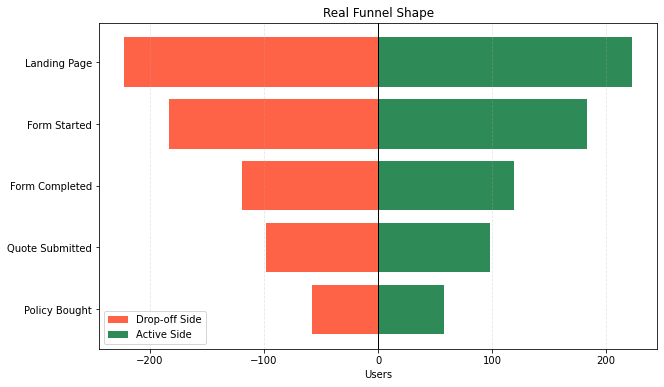

In [29]:
# Sort stages like a real funnel (largest → smallest)
funnel_sorted = funnel_df.sort_values("Users", ascending=False)

stages = funnel_sorted["Stage"]
users = funnel_sorted["Users"]

# Mirrored values
left_side = -users / 2
right_side = users / 2

y = np.arange(len(stages))

plt.figure(figsize=(10,6))

# Left side
plt.barh(y, left_side, color="tomato", label="Drop-off Side")

# Right side
plt.barh(y, right_side, color="seagreen", label="Active Side")

# Center line
plt.axvline(0, color="black", linewidth=1)

plt.yticks(y, stages)
plt.title("Real Funnel Shape")
plt.xlabel("Users")

plt.legend()
plt.grid(axis="x", linestyle="--", alpha=0.3)

plt.gca().invert_yaxis()  # 🔥 makes funnel flow top → bottom

plt.show()
